# OneStop Elementary Scores Analysis

This notebook analyzes the elementary texts score export and lets you compare it against LLM-simplified text results.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_colwidth", 100)
sns.set_theme(style="whitegrid")


In [2]:
ELEMENTARY_SCORES_PATH = Path("data/elemResults")

def read_scores_file(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")
    df = pd.read_csv(path, sep="\t")
    if df.shape[1] == 1:
        df = pd.read_csv(path)
    return df

raw_df = read_scores_file(ELEMENTARY_SCORES_PATH)
raw_df.head()


,Text_id,Tags,Text_Title,Feature_id,Feature_Name,Value
0,320168,NaN,WNL Goodbye fish and chips-ele.txt,953,Lexical Sophistication Feature: BNC (sd LW Type),NaN
1,320168,NaN,WNL Goodbye fish and chips-ele.txt,966,Lexical Sophistication Feature: Kucera and Francis (LW Token),836.804000
2,320168,NaN,WNL Goodbye fish and chips-ele.txt,1107,Lexical Sophistication Feature: SUBTLEX Word Frequency per Million (FW Token),10879.148966
3,320168,NaN,WNL Goodbye fish and chips-ele.txt,781,Lexical Sophistication Feature: Concreteness (LW Type),382.217949
4,320168,NaN,WNL Goodbye fish and chips-ele.txt,332,Lexical Sophistication Feature: Age of Acquisition (LW Type),338.565217


In [3]:
required_cols = {"Text_id", "Text_Title", "Feature_Name", "Value"}
missing_cols = required_cols - set(raw_df.columns)
if missing_cols:
    raise ValueError(f"Missing required columns: {sorted(missing_cols)}")

scores_df = raw_df.copy()
scores_df["Value"] = pd.to_numeric(scores_df["Value"], errors="coerce")
scores_df = scores_df.dropna(subset=["Value"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(scores_df):,}")
print(f"Unique elementary texts: {scores_df['Text_id'].nunique():,}")
print(f"Unique features: {scores_df['Feature_Name'].nunique():,}")


Rows after cleaning: 2,268
Unique elementary texts: 189
Unique features: 12


In [4]:
overall_mean = scores_df["Value"].mean()
feature_means = (
    scores_df.groupby("Feature_Name", as_index=False)["Value"]
    .mean()
    .sort_values("Value", ascending=False)
)
print(f"Overall mean score across all rows: {overall_mean:.4f}")
display(feature_means)


Overall mean score across all rows: 1312.2061


,Feature_Name,Value
6,Lexical Sophistication Feature: SUBTLEX Word Frequency per Million (FW Token),13073.925011
5,Lexical Sophistication Feature: Kucera and Francis (LW Token),1171.310680
4,Lexical Sophistication Feature: Imageability (LW Type),396.590660
3,Lexical Sophistication Feature: Concreteness (LW Type),364.981803
2,Lexical Sophistication Feature: Age of Acquisition (LW Type),346.319832
8,Lexical Sophistication: Easy lexical tokens (BNC),201.708995
0,Lexical Diversity: Measure of Textual Lexical Diversity (MTLD),84.358291
10,Lexical Sophistication: Sophisticated noun tokens (BNC),75.179894
7,Lexical Sophistication: Easy adverb types (BNC),22.248677
11,Readability: Flesch-Kincaid Grade Level,8.197842


In [5]:
RANDOM_SEED = 42
text_pool = scores_df[["Text_id", "Text_Title"]].drop_duplicates().reset_index(drop=True)
picked_text = text_pool.sample(n=1, random_state=RANDOM_SEED).iloc[0]
picked_text_id = picked_text["Text_id"]
picked_text_title = picked_text["Text_Title"]
print(f"Picked text_id: {picked_text_id}")
print(f"Picked text title: {picked_text_title}")


Picked text_id: 320132
Picked text title: WNL A good night sleep-ele.txt


Picked text: WNL A good night sleep-ele.txt (Text_id=320132)
Picked text mean across features: 1375.5784


,Feature_Name,Value
0,Lexical Diversity: Measure of Textual Lexical Diversity (MTLD),69.565308
1,Lexical Richness: Sophisticated Word Type Ratio (BNC),0.215613
2,Lexical Sophistication Feature: Age of Acquisition (LW Type),335.342857
3,Lexical Sophistication Feature: Concreteness (LW Type),359.116505
4,Lexical Sophistication Feature: Imageability (LW Type),392.810811
5,Lexical Sophistication Feature: Kucera and Francis (LW Token),1078.304498
6,Lexical Sophistication Feature: SUBTLEX Word Frequency per Million (FW Token),13950.857143
7,Lexical Sophistication: Easy adverb types (BNC),26.000000
8,Lexical Sophistication: Easy lexical tokens (BNC),236.000000
9,Lexical Sophistication: Sophisticated adverb tokens (BNC),4.000000


C:\Users\Mila Spasova\AppData\Local\Temp\ipykernel_4436\393568751.py:26: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


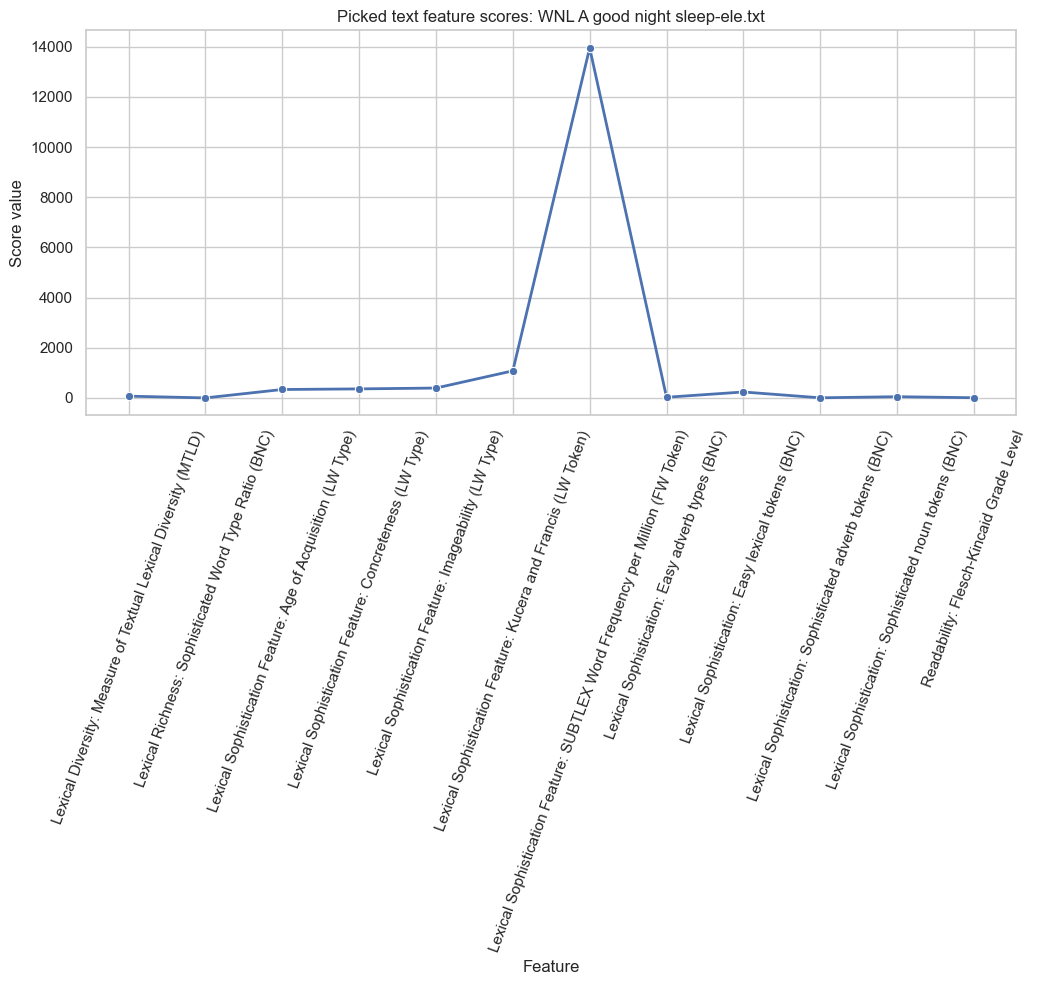

In [6]:
# Easier-to-read view for the picked text only (table + line chart)
picked_text_scores = (
    scores_df[scores_df["Text_id"] == picked_text_id]
    [["Feature_Name", "Value"]]
    .sort_values("Feature_Name")
    .reset_index(drop=True)
)

print(f"Picked text: {picked_text_title} (Text_id={picked_text_id})")
print(f"Picked text mean across features: {picked_text_scores['Value'].mean():.4f}")

display(picked_text_scores)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=picked_text_scores,
    x="Feature_Name",
    y="Value",
    marker="o",
    linewidth=2,
)
plt.title(f"Picked text feature scores: {picked_text_title}")
plt.xlabel("Feature")
plt.ylabel("Score value")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

---

# OneStop Advanced Scores Analysis

Same analysis pipeline as the Elementary section above, applied to the **Advanced** level texts.

In [7]:
ADVANCED_SCORES_PATH = Path("data/advResults")

adv_raw_df = read_scores_file(ADVANCED_SCORES_PATH)
adv_raw_df.head()

,Text_id,Tags,Text_Title,Feature_id,Feature_Name,Value
0,320291,NaN,Kate and William-adv.txt,781,Lexical Sophistication Feature: Concreteness (LW Type),378.709677
1,320291,NaN,Kate and William-adv.txt,332,Lexical Sophistication Feature: Age of Acquisition (LW Type),347.411765
2,320291,NaN,Kate and William-adv.txt,814,Lexical Sophistication Feature: Imageability (LW Type),413.738318
3,320291,NaN,Kate and William-adv.txt,976,Lexical Sophistication: Easy lexical tokens (BNC),192.000000
4,320291,NaN,Kate and William-adv.txt,1060,Lexical Sophistication: Sophisticated noun tokens (BNC),104.000000


In [8]:
adv_required_cols = {"Text_id", "Text_Title", "Feature_Name", "Value"}
adv_missing_cols = adv_required_cols - set(adv_raw_df.columns)
if adv_missing_cols:
    raise ValueError(f"Missing required columns: {sorted(adv_missing_cols)}")

adv_scores_df = adv_raw_df.copy()
adv_scores_df["Value"] = pd.to_numeric(adv_scores_df["Value"], errors="coerce")
adv_scores_df = adv_scores_df.dropna(subset=["Value"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(adv_scores_df):,}")
print(f"Unique advanced texts: {adv_scores_df['Text_id'].nunique():,}")
print(f"Unique features: {adv_scores_df['Feature_Name'].nunique():,}")

Rows after cleaning: 2,268
Unique advanced texts: 189
Unique features: 12


In [9]:
adv_overall_mean = adv_scores_df["Value"].mean()
adv_feature_means = (
    adv_scores_df.groupby("Feature_Name", as_index=False)["Value"]
    .mean()
    .sort_values("Value", ascending=False)
)
print(f"Overall mean score across all rows: {adv_overall_mean:.4f}")
display(adv_feature_means)

Overall mean score across all rows: 1327.6080


,Feature_Name,Value
6,Lexical Sophistication Feature: SUBTLEX Word Frequency per Million (FW Token),13136.535914
5,Lexical Sophistication Feature: Kucera and Francis (LW Token),1100.604430
4,Lexical Sophistication Feature: Imageability (LW Type),401.921205
3,Lexical Sophistication Feature: Concreteness (LW Type),372.214012
2,Lexical Sophistication Feature: Age of Acquisition (LW Type),365.426425
8,Lexical Sophistication: Easy lexical tokens (BNC),278.000000
10,Lexical Sophistication: Sophisticated noun tokens (BNC),121.899471
0,Lexical Diversity: Measure of Textual Lexical Diversity (MTLD),109.865500
7,Lexical Sophistication: Easy adverb types (BNC),28.682540
11,Readability: Flesch-Kincaid Grade Level,11.125590


In [10]:
adv_base_title = picked_text_title.replace("-ele.txt", "-adv.txt")
adv_match = adv_scores_df[adv_scores_df["Text_Title"] == adv_base_title]

if adv_match.empty:
    print(f"No exact match for '{adv_base_title}' in advanced data, falling back to random pick.")
    adv_text_pool = adv_scores_df[["Text_id", "Text_Title"]].drop_duplicates().reset_index(drop=True)
    adv_picked = adv_text_pool.sample(n=1, random_state=RANDOM_SEED).iloc[0]
    adv_picked_text_id = adv_picked["Text_id"]
    adv_picked_text_title = adv_picked["Text_Title"]
else:
    adv_picked_text_id = adv_match.iloc[0]["Text_id"]
    adv_picked_text_title = adv_base_title

print(f"Picked text_id: {adv_picked_text_id}")
print(f"Picked text title: {adv_picked_text_title}")

Picked text_id: 320326
Picked text title: WNL A good night sleep-adv.txt


Picked text: WNL A good night sleep-adv.txt (Text_id=320326)
Picked text mean across features: 1400.1897


,Feature_Name,Value
0,Lexical Diversity: Measure of Textual Lexical Diversity (MTLD),77.716332
1,Lexical Richness: Sophisticated Word Type Ratio (BNC),0.323684
2,Lexical Sophistication Feature: Age of Acquisition (LW Type),340.434783
3,Lexical Sophistication Feature: Concreteness (LW Type),365.603053
4,Lexical Sophistication Feature: Imageability (LW Type),396.507143
5,Lexical Sophistication Feature: Kucera and Francis (LW Token),1090.852151
6,Lexical Sophistication Feature: SUBTLEX Word Frequency per Million (FW Token),14099.240870
7,Lexical Sophistication: Easy adverb types (BNC),32.000000
8,Lexical Sophistication: Easy lexical tokens (BNC),286.000000
9,Lexical Sophistication: Sophisticated adverb tokens (BNC),9.000000


C:\Users\Mila Spasova\AppData\Local\Temp\ipykernel_4436\1039927410.py:25: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


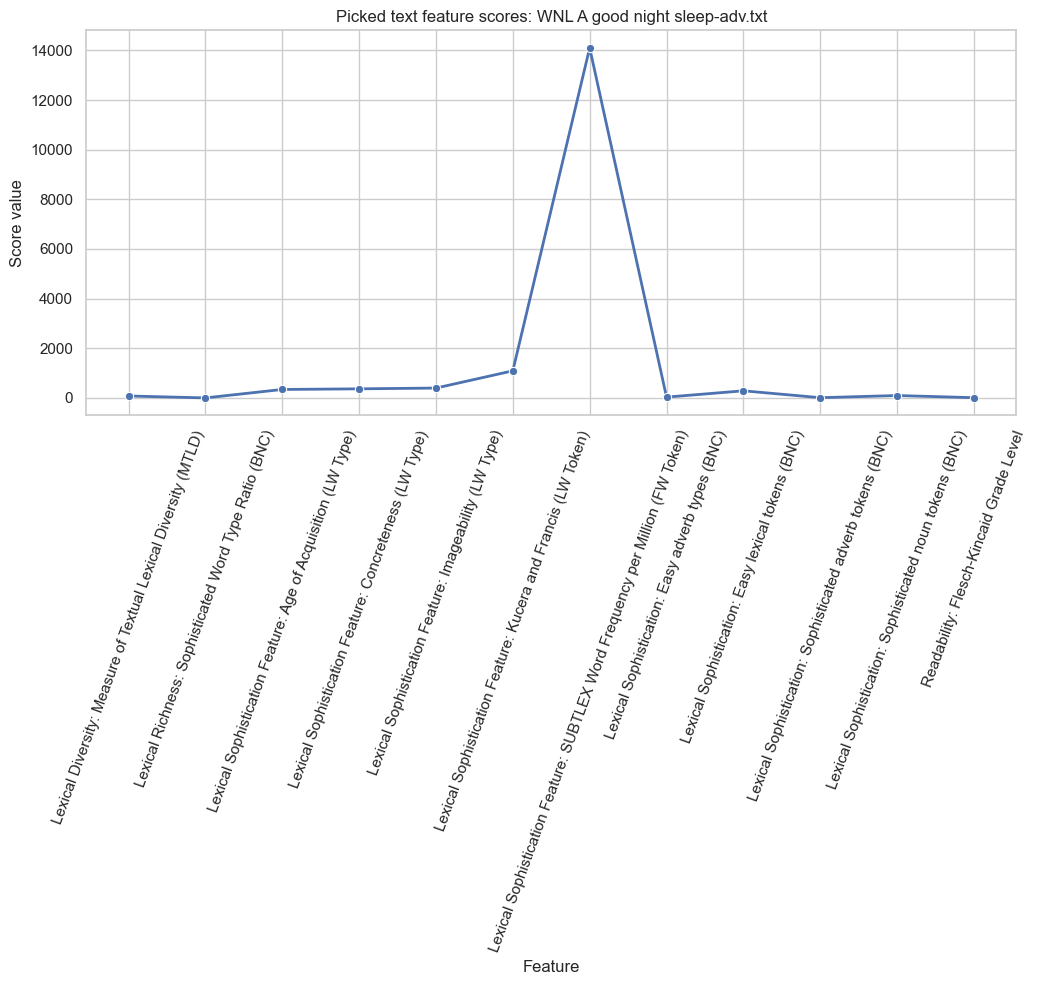

In [11]:
adv_picked_text_scores = (
    adv_scores_df[adv_scores_df["Text_id"] == adv_picked_text_id]
    [["Feature_Name", "Value"]]
    .sort_values("Feature_Name")
    .reset_index(drop=True)
)

print(f"Picked text: {adv_picked_text_title} (Text_id={adv_picked_text_id})")
print(f"Picked text mean across features: {adv_picked_text_scores['Value'].mean():.4f}")

display(adv_picked_text_scores)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=adv_picked_text_scores,
    x="Feature_Name",
    y="Value",
    marker="o",
    linewidth=2,
)
plt.title(f"Picked text feature scores: {adv_picked_text_title}")
plt.xlabel("Feature")
plt.ylabel("Score value")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

---

# LLM-Simplified Text Scores Analysis

Same analysis pipeline applied to **LLM-simplified** texts.

> **TODO:** Replace `LLM_RESULTS_PATH` below with the path to your LLM results CSV once you create it.

In [12]:
LLM_RESULTS_PATH = Path("data/PLACEHOLDER_llm_results.csv")  # <-- change this to your actual LLM results file

llm_raw_df = read_scores_file(LLM_RESULTS_PATH)
llm_raw_df.head()

FileNotFoundError: File not found: data\PLACEHOLDER_llm_results.csv

In [ ]:
llm_required_cols = {"Text_id", "Text_Title", "Feature_Name", "Value"}
llm_missing_cols = llm_required_cols - set(llm_raw_df.columns)
if llm_missing_cols:
    raise ValueError(f"Missing required columns: {sorted(llm_missing_cols)}")

llm_scores_df = llm_raw_df.copy()
llm_scores_df["Value"] = pd.to_numeric(llm_scores_df["Value"], errors="coerce")
llm_scores_df = llm_scores_df.dropna(subset=["Value"]).reset_index(drop=True)

print(f"Rows after cleaning: {len(llm_scores_df):,}")
print(f"Unique LLM texts: {llm_scores_df['Text_id'].nunique():,}")
print(f"Unique features: {llm_scores_df['Feature_Name'].nunique():,}")

In [ ]:
llm_overall_mean = llm_scores_df["Value"].mean()
llm_feature_means = (
    llm_scores_df.groupby("Feature_Name", as_index=False)["Value"]
    .mean()
    .sort_values("Value", ascending=False)
)
print(f"Overall mean score across all rows: {llm_overall_mean:.4f}")
display(llm_feature_means)

In [ ]:
llm_match = llm_scores_df[llm_scores_df["Text_Title"] == picked_text_title]

if llm_match.empty:
    llm_base_title = picked_text_title.replace("-ele.txt", "")
    llm_match = llm_scores_df[llm_scores_df["Text_Title"].str.contains(llm_base_title, regex=False)]

if llm_match.empty:
    print(f"No match for '{picked_text_title}' in LLM data, falling back to random pick.")
    llm_text_pool = llm_scores_df[["Text_id", "Text_Title"]].drop_duplicates().reset_index(drop=True)
    llm_picked = llm_text_pool.sample(n=1, random_state=RANDOM_SEED).iloc[0]
    llm_picked_text_id = llm_picked["Text_id"]
    llm_picked_text_title = llm_picked["Text_Title"]
else:
    llm_picked_text_id = llm_match.iloc[0]["Text_id"]
    llm_picked_text_title = llm_match.iloc[0]["Text_Title"]

print(f"Picked text_id: {llm_picked_text_id}")
print(f"Picked text title: {llm_picked_text_title}")

In [ ]:
llm_picked_text_scores = (
    llm_scores_df[llm_scores_df["Text_id"] == llm_picked_text_id]
    [["Feature_Name", "Value"]]
    .sort_values("Feature_Name")
    .reset_index(drop=True)
)

print(f"Picked text: {llm_picked_text_title} (Text_id={llm_picked_text_id})")
print(f"Picked text mean across features: {llm_picked_text_scores['Value'].mean():.4f}")

display(llm_picked_text_scores)

plt.figure(figsize=(12, 5))
sns.lineplot(
    data=llm_picked_text_scores,
    x="Feature_Name",
    y="Value",
    marker="o",
    linewidth=2,
)
plt.title(f"Picked text feature scores: {llm_picked_text_title}")
plt.xlabel("Feature")
plt.ylabel("Score value")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()